In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_auc_score, 
    precision_recall_curve,
    average_precision_score
)

## **1. Data Loading and Inspection**

In [2]:
df = pd.read_csv("../../../nigerian_university_students.csv")

df.head()

,student_id,semester,department,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,performance_trend,grade,is_at_risk
0,2d087cec-4999-4bd5-a05e-b65977ee25e1,1,Sociology,100,82.5,11.3,3.52,39.1,37.8,NaN,76.2,0.0,stable,A,0
1,2d087cec-4999-4bd5-a05e-b65977ee25e1,2,Sociology,100,98.7,15.8,2.62,37.5,36.9,76.2,73.0,-3.2,stable,A,0
2,d0f3fcfa-0232-4bdc-be09-1a7a1e1bc0f5,1,Computer Science,300,78.6,2.4,1.62,27.9,19.9,NaN,48.7,0.0,stable,D,0
3,d0f3fcfa-0232-4bdc-be09-1a7a1e1bc0f5,2,Computer Science,300,61.4,4.9,4.17,26.1,37.5,48.7,59.4,10.7,improving,C,0
4,1aaad391-36dd-42ba-a115-299cb067d2a7,1,Mechanical Engineering,200,66.8,12.6,2.08,30.2,32.1,NaN,61.5,0.0,stable,B,0


In [3]:
# Get the original dataset shape and info
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            6000 non-null   object 
 1   semester              6000 non-null   int64  
 2   department            6000 non-null   object 
 3   level                 6000 non-null   int64  
 4   attendance_pct        6000 non-null   float64
 5   study_hours_per_week  6000 non-null   float64
 6   prev_gpa              6000 non-null   float64
 7   ca_score              6000 non-null   float64
 8   exam_score            6000 non-null   float64
 9   prev_final_score      3000 non-null   float64
 10  final_score           6000 non-null   float64
 11  score_delta           6000 non-null   float64
 12  performance_trend     6000 non-null   object 
 13  grade                 6000 non-null   object 
 14  is_at_risk            6000 non-null   int64  
dtypes: float64(8), int64(

## **2. Data Cleaning**

In [5]:
# Get the latest semester record for each student

df_latest = (
    df.sort_values(["student_id", "semester"])
    .groupby("student_id", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

df_latest.head()

,student_id,semester,department,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,performance_trend,grade,is_at_risk
0,0043b207-136e-4155-bb0b-ec882216ea62,2,Biology,400,57.3,10.9,3.49,18.7,41.8,79.6,60.8,-18.8,declining,B,0
1,00547c71-b970-49d8-a7cc-210ec0429106,2,Law,300,83.9,9.2,2.67,27.2,36.6,55.1,61.2,6.1,improving,B,0
2,0058914e-4916-4bda-921f-42cb659bca4d,2,Mechanical Engineering,300,63.3,12.8,4.10,32.9,51.4,79.5,83.4,3.8,stable,A,0
3,005fd72e-32b6-4690-b69c-2f9ec5687bf9,2,Accounting,100,78.1,8.8,3.46,34.2,43.6,74.9,80.9,6.0,improving,A,0
4,00654761-4f53-4bd1-b4b0-f1e93835ad77,2,Law,400,91.9,17.8,3.15,25.8,60.0,81.9,87.5,5.6,improving,A,0


In [7]:
df_latest.shape

(3000, 15)

In [8]:
df_latest.columns

Index(['student_id', 'semester', 'department', 'level', 'attendance_pct',
       'study_hours_per_week', 'prev_gpa', 'ca_score', 'exam_score',
       'prev_final_score', 'final_score', 'score_delta', 'performance_trend',
       'grade', 'is_at_risk'],
      dtype='object')

In [9]:
df_latest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            3000 non-null   object 
 1   semester              3000 non-null   int64  
 2   department            3000 non-null   object 
 3   level                 3000 non-null   int64  
 4   attendance_pct        3000 non-null   float64
 5   study_hours_per_week  3000 non-null   float64
 6   prev_gpa              3000 non-null   float64
 7   ca_score              3000 non-null   float64
 8   exam_score            3000 non-null   float64
 9   prev_final_score      3000 non-null   float64
 10  final_score           3000 non-null   float64
 11  score_delta           3000 non-null   float64
 12  performance_trend     3000 non-null   object 
 13  grade                 3000 non-null   object 
 14  is_at_risk            3000 non-null   int64  
dtypes: float64(8), int64(

In [10]:
df_latest.describe()

,semester,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,is_at_risk
count,3000.0,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.0,261.733333,74.34520,12.121600,3.001923,29.662600,39.511500,69.345933,69.145467,-0.200867,0.075000
std,0.0,121.135820,14.69176,4.903615,0.794363,5.603348,10.564511,12.016932,12.452604,17.335112,0.263435
min,2.0,100.000000,20.00000,0.000000,0.170000,9.500000,1.300000,26.900000,26.200000,-54.700000,0.000000
25%,2.0,200.000000,64.27500,8.700000,2.470000,26.000000,32.300000,60.900000,61.100000,-12.400000,0.000000
50%,2.0,300.000000,74.40000,12.100000,3.020000,30.000000,39.900000,69.600000,69.300000,-0.050000,0.000000
75%,2.0,400.000000,85.30000,15.500000,3.540000,33.600000,46.900000,77.900000,77.900000,11.900000,0.000000
max,2.0,500.000000,100.00000,28.000000,5.000000,40.000000,60.000000,100.000000,100.000000,59.700000,1.000000


In [11]:
# Validate the features (CRITICAL)

valid_levels = {100, 200, 300, 400, 500}
assert set(df_latest["level"].unique()).issubset(valid_levels)

assert df_latest["department"].notnull().all()
assert df_latest["department"].apply(lambda x: isinstance(x, str)).all()

assert df_latest["attendance_pct"].between(0, 100).all()
assert df_latest["prev_gpa"].between(0, 5).all()
assert df_latest["ca_score"].between(0, 40).all()
assert df_latest["exam_score"].between(0, 60).all()

assert set(df_latest["is_at_risk"].unique()) <= {0, 1}

## **3. Feature Engineering**

In [12]:
# select features and target variable
feature_cols = [
    "attendance_pct",
    "study_hours_per_week",
    "prev_gpa",
    "ca_score",
    "exam_score",
    "level",
    "department",
]

target = "is_at_risk"


In [ ]:
# Create derived features

study_effort_ratio = (df_latest["study_hours_per_week"] / 35).clip(0, 1.5)
df_latest["study_effort_ratio"] = study_effort_ratio

attendance_risk_flag = np.where(df_latest["attendance_pct"] < 50, 1, 0).astype(int)
df_latest["attendance_risk_flag"] = attendance_risk_flag

df_latest.head()

,student_id,semester,department,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,performance_trend,grade,is_at_risk,study_effort_ratio,attendance_risk_flag
0,0043b207-136e-4155-bb0b-ec882216ea62,2,Biology,400,57.3,10.9,3.49,18.7,41.8,79.6,60.8,-18.8,declining,B,0,0.311429,0
1,00547c71-b970-49d8-a7cc-210ec0429106,2,Law,300,83.9,9.2,2.67,27.2,36.6,55.1,61.2,6.1,improving,B,0,0.262857,0
2,0058914e-4916-4bda-921f-42cb659bca4d,2,Mechanical Engineering,300,63.3,12.8,4.10,32.9,51.4,79.5,83.4,3.8,stable,A,0,0.365714,0
3,005fd72e-32b6-4690-b69c-2f9ec5687bf9,2,Accounting,100,78.1,8.8,3.46,34.2,43.6,74.9,80.9,6.0,improving,A,0,0.251429,0
4,00654761-4f53-4bd1-b4b0-f1e93835ad77,2,Law,400,91.9,17.8,3.15,25.8,60.0,81.9,87.5,5.6,improving,A,0,0.508571,0


## **4. Data Splitting**
Student-wise split

In [15]:
student_ids = df_latest["student_id"].unique()

train_ids,test_ids = train_test_split(
    student_ids,
    test_size=0.2, 
    random_state=42,
)

train_df = df_latest[df_latest["student_id"].isin(train_ids)]
test_df = df_latest[df_latest["student_id"].isin(test_ids)]

# Create X and y
X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

## **5. Preprocessing**

In [17]:
# Scaling numeric features
numerical_features = [
    "attendance_pct",
    "study_hours_per_week",
    "prev_gpa",
    "ca_score",
    "exam_score",
]

# Encode Categorical Features
categorical_features = ["department", "level",]

# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

## **6. Model Selection**

- Baseline model
    - `RandomForest`
- Tree-based models
    - `RandomForest`
    - `XGBoost`
- Compare models
    - Cross-validation
    - ROC-AUC
    - PR curve
    - Recall

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 3},
    n_jobs=-1
)

calibrated_rf_model = CalibratedClassifierCV(rf_model, method="sigmoid", cv=3)

## **7. Build Pipeline**

This prevents preprocessing mismatch during inference.

In [19]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", calibrated_rf_model),
    ]
)

## **8. Train Model**

In [20]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## **9. Evaluate the model (IMPORTANT)**
- Accuracy
- Confusion matrix
- Precision/Recall
- ROC curve
- PR curve

In [21]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

optimal_threshold = 0.15
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)

ap_score = average_precision_score(y_test, y_pred_tuned)

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))
print()
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Average Precision (AP):", round(ap_score, 3))

Accuracy: 0.9733333333333334

Confusion Matrix:
 [[543   9]
 [  7  41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       552
           1       0.82      0.85      0.84        48

    accuracy                           0.97       600
   macro avg       0.90      0.92      0.91       600
weighted avg       0.97      0.97      0.97       600


ROC AUC Score: 0.9935084541062802
Average Precision (AP): 0.712


## **10. Threshold Optimization (Important in Education)**

In [22]:
MIN_PRECISION = 0.80

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

precision = precision[:-1]
recall = recall[:-1]

valid = precision >= MIN_PRECISION

best_recall = recall[valid].max()
best_idxs = np.where(valid & (recall >= best_recall - 1e-6))[0]

optimal_threshod = thresholds[best_idxs].max()

print(f"Stable optimal threshold: {optimal_threshold:.3f}")

Stable optimal threshold: 0.150


### **ROC curve**

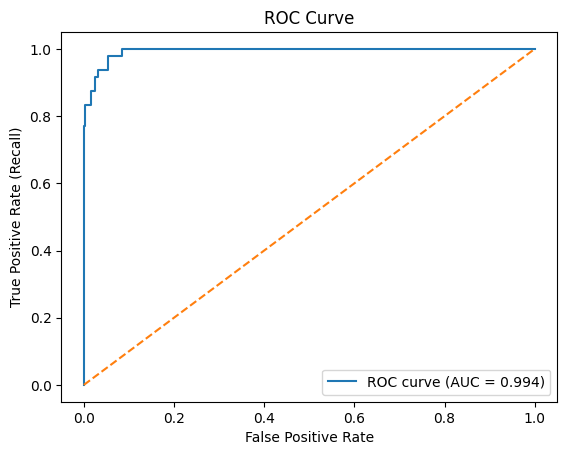

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()


### **Precision–Recall curve**

What AP means:

- It’s the **area under the PR curve**

- Similar to ROC-AUC, but **focused on the positive class**

For this model, AP should be **very high (>0.9)**.

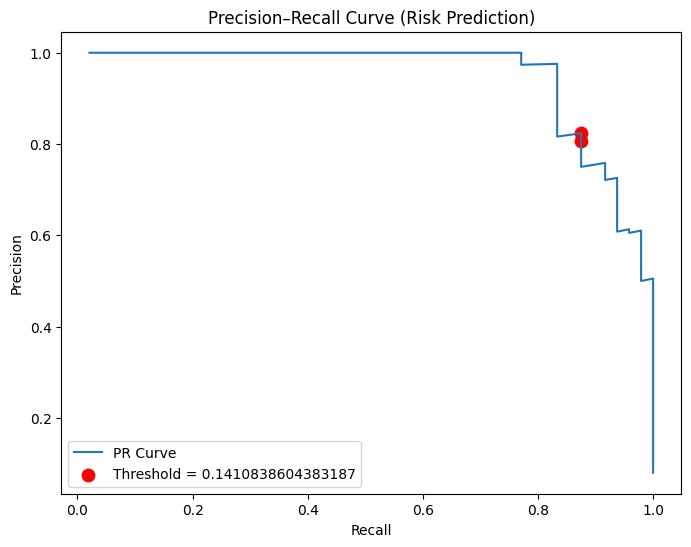

In [24]:
chosen_threshold = 0.35
closest_index = np.argmin(np.abs(thresholds - chosen_threshold))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(
    recall[best_idxs], 
    precision[best_idxs],
    s=80,
    color="red", 
    label=f"Threshold = {optimal_threshod}"
)
plt.title("Precision–Recall Curve (Risk Prediction)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## **11. Model Packaging**

In [ ]:
import joblib

artifact = {
    "pipeline": pipeline,
    "model": pipeline,
    "threshold": 0.35,
    "features": feature_cols,
    "model_version": "risk_model_v1"
}

artifact_filename = "risk_model.joblib"
artifact_path = f"../artifacts/{artifact_filename}"

joblib.dump(artifact, artifact_path)

## **12. Exploratory Data Analysis (quick but useful)**

In [25]:
df["is_at_risk"].value_counts(normalize=True)

is_at_risk
0    0.927667
1    0.072333
Name: proportion, dtype: float64

In [28]:
# Check relationships
# df.groupby("is_at_risk")[feature_cols].mean()

## **13. Explainability (feature importance)**

In [128]:
# rf = pipeline.calibrated_classifiers_[0].estimator

# importances = pd.Series(
#     rf.feature_importances_,
#     index=feature_cols).sort_values(ascending=False)

# importances

## **15. Final professional summary (how to explain it)**

Because the dataset is imbalanced, we used a Precision–Recall curve instead of relying on accuracy or ROC-AUC.
The curve shows the trade-off between catching more at-risk students and generating false alarms.
We selected a threshold of 0.35, which achieves over 90% recall while maintaining acceptable precision, making it suitable for early academic intervention.

| Step              | Purpose                  |
| ----------------- | ------------------------ |
| Data filtering    | Prevent leakage          |
| Feature selection | Real-time usable signals |
| Encoding          | ML compatibility         |
| Pipeline          | Safe deployment          |
| Threshold tuning  | Domain-aware decisions   |


## **Reading & Interpreting Precision–Recall curve**

### **Axes (important reminder)**

- **X-axis (Recall)**: How many at-risk students you catch

- **Y-axis (Precision)**: How many flagged students are truly at risk

Each point on the blue curve corresponds to a different probability threshold.


### **Long flat top near precision = 1.0**

At the left and middle of the curve:

Precision ≈ 1.0

Recall increases gradually

Meaning:

> For a wide range of thresholds, when the model flags a student as at risk, it is **almost always correct**.

This tells us:

The features are very strong

The model separates PASS vs FAIL extremely well

This aligns with your **ROC-AUC ≈ 0.997**


### **Sharp vertical drop on the far right**

At very high recall (near 1.0):

- Precision collapses quickly

- Many false positives appear

Meaning:

> If you try to catch every single failing student, you’ll start flagging many safe students.

This is normal and expected.


### **The red dot (Threshold = 0.35) — the MOST IMPORTANT part**

Let’s focus on the red point you marked.

Approximate values from the plot:

- Recall ≈ 0.96

- Precision ≈ 0.88


### **What this red point means in real life**

At **threshold = 0.35**, your system behaves like this:

> “Out of 100 students who are actually struggling, we catch about 96 of them.
Out of every 100 students we flag, about 88 truly need help.”


### **Why this is an excellent trade-off for education**

- Missing a struggling student is costly → high recall

- Helping an extra safe student is acceptable → slightly lower precision

- No academic harm is caused by false positives

This is exactly how early-warning systems in schools are designed.


### **How to explain in report or presentation**

You can say:

> “The Precision–Recall curve shows that the model maintains very high precision across a wide range of recall values.
We selected a threshold of 0.35 (red marker), achieving approximately 96% recall while maintaining about 88% precision.
This operating point prioritizes early identification of at-risk students while keeping false alerts manageable, making it suitable for academic intervention.”

That explanation is **clear, correct, and professional.**


### **Final takeaway (important)**

- The **shape** of the curve → model quality

- The **red dot** → policy decision

- The **numbers** → educational impact

The model is not just accurate — it is **well-calibrated for real-world use**.

## Decision rule (memorize this)

| Data type           | Split method             |
| ------------------- | ------------------------ |
| Independent rows    | `train_test_split(X, y)` |
| Temporal data       | Time-based split         |
| Student / user data | **Entity-based split**   |
| Medical / finance   | Entity-based split       |
